# Đề tài: Phân tích hiệu quả kinh doanh và xây dựng mô hình dự báo doanh thu cho chuỗi siêu thị đa chi nhánh tại Myanmar

## Data Dictionary:
- Invoice ID – Unique identifier for each transaction/invoice.
- Branch – Branch code of the supermarket (e.g., A, B, C).
- City – City where the supermarket branch is located.
- Customer type – Type of customer (e.g., Member, Normal).
- Gender – Gender of the customer.
- Product line – Product category (e.g., Health and beauty, Electronic - accessories, Food and beverages).
- Unit price – Price of a single product unit.
- Quantity – Number of product units purchased.
- Tax 5% – 5% tax amount applied to the purchase.
- Total – Total price including tax.
- Date – Date of purchase.
- Time – Time of purchase.
- Payment – Payment method (e.g., Cash, Credit card, Ewallet).
- cogs – Cost of goods sold (before tax).
- gross margin percentage – Gross margin percentage for the transaction.
- gross income – Profit earned from the transaction (cogs × margin).
- Rating – Customer satisfaction rating (typically 1–10).

## Tiếng Việt:
- Invoice ID – Mã định danh duy nhất cho mỗi giao dịch/hóa đơn.
- Branch – Mã chi nhánh của siêu thị (ví dụ: A, B, C).
- City – Thành phố nơi chi nhánh siêu thị tọa lạc.
- Customer type – Loại khách hàng (ví dụ: Thành viên, Khách hàng thông thường).
- Gender – Giới tính của khách hàng.
- Product line – Danh mục sản phẩm (ví dụ: Sức khỏe và sắc đẹp, Điện tử - phụ kiện, Thực phẩm và đồ uống).
- Unit price – Giá của một đơn vị sản phẩm.
- Quantity – Số lượng đơn vị sản phẩm đã mua.
- Tax 5% – Thuế suất 5% áp dụng cho giao dịch mua.
- Total – Tổng giá bao gồm thuế.
- Date – Ngày mua hàng.
- Time – Giờ mua hàng.
- Payment – Phương thức thanh toán (ví dụ: Tiền mặt, Thẻ tín dụng, Ví điện tử).
- cogs – Giá vốn hàng bán (trước thuế).
- gross margin percentage – Tỷ lệ lợi nhuận gộp của giao dịch. 
- gross income – Lợi nhuận thu được từ giao dịch (giá vốn hàng bán × tỷ suất lợi nhuận).
- Rating – Mức độ hài lòng của khách hàng (thường từ 1–10).

# Import thư viện và Đọc dữ liệu

In [14]:
# Cài đặt thư viện xử
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Tiền xử lý dữ liệu
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from imblearn.over_sampling import SMOTE

# Mô hình Machine Learning
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

# Đánh giá mô hình
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, roc_auc_score, roc_curve

In [15]:
path = './data/Supermarket_sales.csv'

df = pd.read_csv(path)

In [16]:
df.head()

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,13:08,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,3/8/2019,10:29,Cash,76.40,4.761905,3.8200,9.6
2,631-41-3108,A,Yangon,Normal,Male,Home and lifestyle,46.33,7,16.2155,340.5255,3/3/2019,13:23,Credit card,324.31,4.761905,16.2155,7.4
3,123-19-1176,A,Yangon,Member,Male,Health and beauty,58.22,8,23.2880,489.0480,1/27/2019,20:33,Ewallet,465.76,4.761905,23.2880,8.4
4,373-73-7910,A,Yangon,Normal,Male,Sports and travel,86.31,7,30.2085,634.3785,2/8/2019,10:37,Ewallet,604.17,4.761905,30.2085,5.3


In [17]:
df.tail()

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
995,233-67-5758,C,Naypyitaw,Normal,Male,Health and beauty,40.35,1,2.0175,42.3675,1/29/2019,13:46,Ewallet,40.35,4.761905,2.0175,6.2
996,303-96-2227,B,Mandalay,Normal,Female,Home and lifestyle,97.38,10,48.6900,1022.4900,3/2/2019,17:16,Ewallet,973.80,4.761905,48.6900,4.4
997,727-02-1313,A,Yangon,Member,Male,Food and beverages,31.84,1,1.5920,33.4320,2/9/2019,13:22,Cash,31.84,4.761905,1.5920,7.7
998,347-56-2442,A,Yangon,Normal,Male,Home and lifestyle,65.82,1,3.2910,69.1110,2/22/2019,15:33,Cash,65.82,4.761905,3.2910,4.1
999,849-09-3807,A,Yangon,Member,Female,Fashion accessories,88.34,7,30.9190,649.2990,2/18/2019,13:28,Cash,618.38,4.761905,30.9190,6.6


# Data Preparation / Data Preprocessing / EDA

## Data Understanding (Thấu hiểu dữ liệu)

In [13]:
df.shape

# Data có 1000 dòng và 17 cột

(1000, 17)

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   Invoice ID               1000 non-null   object 
 1   Branch                   1000 non-null   object 
 2   City                     1000 non-null   object 
 3   Customer type            1000 non-null   object 
 4   Gender                   1000 non-null   object 
 5   Product line             1000 non-null   object 
 6   Unit price               1000 non-null   float64
 7   Quantity                 1000 non-null   int64  
 8   Tax 5%                   1000 non-null   float64
 9   Total                    1000 non-null   float64
 10  Date                     1000 non-null   object 
 11  Time                     1000 non-null   object 
 12  Payment                  1000 non-null   object 
 13  cogs                     1000 non-null   float64
 14  gross margin percentage  

In [10]:
df.describe()

,Unit price,Quantity,Tax 5%,Total,cogs,gross margin percentage,gross income,Rating
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000,1000.00000
mean,55.672130,5.510000,15.379369,322.966749,307.58738,4.761905,15.379369,6.97270
std,26.494628,2.923431,11.708825,245.885335,234.17651,0.000000,11.708825,1.71858
min,10.080000,1.000000,0.508500,10.678500,10.17000,4.761905,0.508500,4.00000
25%,32.875000,3.000000,5.924875,124.422375,118.49750,4.761905,5.924875,5.50000
50%,55.230000,5.000000,12.088000,253.848000,241.76000,4.761905,12.088000,7.00000
75%,77.935000,8.000000,22.445250,471.350250,448.90500,4.761905,22.445250,8.50000
max,99.960000,10.000000,49.650000,1042.650000,993.00000,4.761905,49.650000,10.00000


In [11]:
df.describe(include='object')	

,Invoice ID,Branch,City,Customer type,Gender,Product line,Date,Time,Payment
count,1000,1000,1000,1000,1000,1000,1000,1000,1000
unique,1000,3,3,2,2,6,89,506,3
top,750-67-8428,A,Yangon,Member,Female,Fashion accessories,2/7/2019,19:48,Ewallet
freq,1,340,340,501,501,178,20,7,345


In [ ]:
df.nunique()

# Có 3 branch: A, B, C
# Ở 3 thành phố: Yangon, Mandalay, Naypyitaw
# 2 loại khách hàng: Member và Normal
# 6 Produt line: Fashion accessories, Food and beverages, Electronic accessories, Sports and travel, Home and lifestyle, Health and beauty
# 3 loại thanh toán: Cash, Credit card, Ewallet

Invoice ID                 1000
Branch                        3
City                          3
Customer type                 2
Gender                        2
Product line                  6
Unit price                  943
Quantity                     10
Tax 5%                      990
Total                       990
Date                         89
Time                        506
Payment                       3
cogs                        990
gross margin percentage       1
gross income                990
Rating                       61
dtype: int64

## Data Cleaning (Dọn dẹp dữ liệu)

In [22]:
df.isnull().sum()

Invoice ID                 0
Branch                     0
City                       0
Customer type              0
Gender                     0
Product line               0
Unit price                 0
Quantity                   0
Tax 5%                     0
Total                      0
Date                       0
Time                       0
Payment                    0
cogs                       0
gross margin percentage    0
gross income               0
Rating                     0
dtype: int64

In [27]:
df.duplicated().sum()

0

In [ ]:
df.dtypes

# Date và Time đang ở dạng object, cần chuyển về datetime
# Branch, City, Customer type, Gender, Product line, và Payment đang ở dạng object, cần chuyển về category

Invoice ID                  object
Branch                      object
City                        object
Customer type               object
Gender                      object
Product line                object
Unit price                 float64
Quantity                     int64
Tax 5%                     float64
Total                      float64
Date                        object
Time                        object
Payment                     object
cogs                       float64
gross margin percentage    float64
gross income               float64
Rating                     float64
dtype: object

In [29]:
# 1. Chuyển đổi ngày tháng
df['Date'] = pd.to_datetime(df['Date'])
df['Time'] = pd.to_datetime(df['Time']).dt.time # Hoặc giữ nguyên datetime tùy mục đích

# 2. Chuyển đổi các cột phân loại
category_cols = ['Branch', 'City', 'Customer type', 'Gender', 'Product line', 'Payment']
for col in category_cols:
    df[col] = df[col].astype('category')
    
df.dtypes

Invoice ID                         object
Branch                           category
City                             category
Customer type                    category
Gender                           category
Product line                     category
Unit price                        float64
Quantity                            int64
Tax 5%                            float64
Total                             float64
Date                       datetime64[ns]
Time                               object
Payment                          category
cogs                              float64
gross margin percentage           float64
gross income                      float64
Rating                            float64
dtype: object

In [32]:
quantCols = ['Unit price', 'Tax 5%', 'Quantity', 'Total']

# Kiểm tra xem có giá trị âm không
negCounts = (df[quantCols] < 0).sum()
negCounts

#không có giá trị âm ở các cột số lượng

Unit price    0
Tax 5%        0
Quantity      0
Total         0
dtype: int64

## Univariate Analysis (Phân tích đơn biến)

In [33]:
df.head(2)

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,2019-01-05,13:08:00,Ewallet,522.83,4.761905,26.1415,9.1
1,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,2019-03-08,10:29:00,Cash,76.40,4.761905,3.8200,9.6


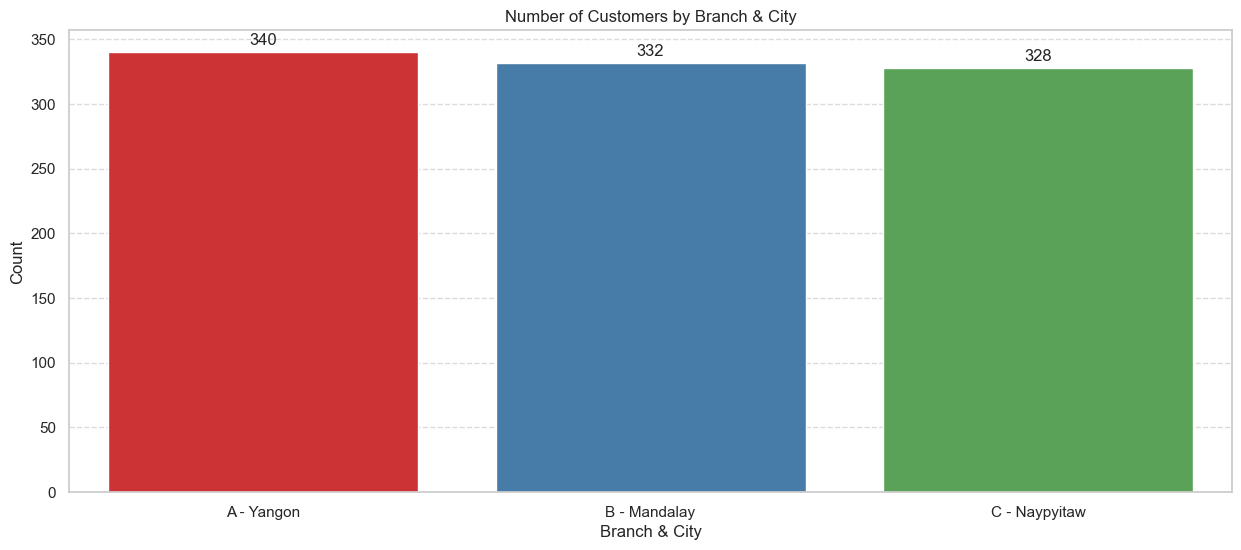

In [ ]:
# Branch và City có mối quan hệ 1-1

plt.figure(figsize=(15, 6))
ax = sns.countplot(x='Branch', data=df, palette='Set1')
custom_labels = ['A - Yangon', 'B - Mandalay', 'C - Naypyitaw']
ax.set_xticklabels(custom_labels)

for container in ax.containers:
    ax.bar_label(container, fmt='%d', padding=3)

plt.title('Number of Customers by Branch & City')
plt.xlabel('Branch & City')
plt.ylabel('Count')
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()